# TabPFN model — mortgage approval (2025 HMDA LAR)

Fits the TabPFN model: feature selection, context size, the fit itself, and the model's statistical
performance on validation and test.

**Out of scope here** (run in separate notebooks for all three models): interpretability,
stability and fairness. This notebook only produces the model and the scores those steps consume.

**Inputs:** `data/processed/{train,val,test}.parquet` from `data_cleaning.ipynb` (same fixed split
as the rest of the team).

**Outputs** (git-ignored — regenerate by running this notebook):
- `models/tabpfn_model.joblib` — the model: context rows, category codes and settings (~3 MB)
- `data/tabpfn-results/test_predictions_with_sensitive.parquet` (and `val_…`) — one row per
  applicant, indexed by `row_nr`: audit columns, `true_target`, `predicted_probability`,
  `predicted_label`
- `data/tabpfn-results/` — `metrics_summary.txt`, `run_config.json` (settings, versions, timings),
  `feature_audit.csv`, `speed_check.csv` and the charts

`row_nr` is the row's position in its split file. The splits have no ID column, so this is what
joins TabPFN's scores to any other model's scores on the same applicants.

**Shared interface.** The model lives in `src/tabpfn_model.py` and exposes
`fit(X_train, y_train) -> model` and `predict_proba(model, X) -> (n, 2)`, like
`src/xgboost_model.py`. `X` is the *cleaned* DataFrame — feature selection, context sampling and
encoding all happen inside.

**What TabPFN is.** A transformer pre-trained on millions of synthetic tables. It has no training of
its own: `fit` stores a *context* (a stratified sample of training rows), and every prediction reads
that context together with the rows being scored. There is no hyper-parameter tuning; the choices
are the model version, the context size and the number of estimators.

**Model version: TabPFN-3.5** (`tabpfn==9.0.0`), the latest release, run on the lab GPU machines. Its
weights are gated behind a free licence: put your Prior Labs API key in `~/.tabpfn/token` or the
`TABPFN_TOKEN` environment variable — never in this notebook.

**Runtime** (lab machine, RTX 4000 Ada, rough): loading ~1 min, speed check ~5 min, full test split
(1.37M rows) ~7 min. On a CPU, the defaults below switch to a smaller context and scored subsets
(~25 min in total).

In [1]:
import json
import sys
import time
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import sklearn
import tabpfn
import torch
from sklearn.calibration import CalibrationDisplay
from sklearn.metrics import (accuracy_score, average_precision_score, brier_score_loss,
                             confusion_matrix, f1_score, log_loss, precision_score, recall_score,
                             roc_auc_score, roc_curve)

sys.path.insert(0, str(Path("../src").resolve()))
import tabpfn_model as tm

warnings.filterwarnings("ignore", message=".*CPU.*")  # TabPFN's "CPU may be slow" notice

DATA_DIR = Path("../data/processed")
MODELS_DIR = Path("../models")
OUT_DIR = Path("../data/tabpfn-results")
MODELS_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = tm.RANDOM_STATE  # 42, as everywhere in the team
TARGET = "target"
DEVICE = tm.device()
ON_GPU = DEVICE == "cuda"

# Model
MODEL_VERSION = tm.MODEL_VERSION               # "v3.5"
CONTEXT_ROWS = tm.CONTEXT_ROWS if ON_GPU else 2_500
N_ESTIMATORS = tm.N_ESTIMATORS                 # 4, see section 3

# Scoring
VAL_ROWS = 20_000 if ON_GPU else 5_000         # validation rows scored for the metrics
TEST_ROWS = None if ON_GPU else 5_000          # None = the full test split
THRESHOLD = 0.5                                # for predicted_label; same cut-off as the log-reg notebook

# Speed check (section 3)
RUN_SPEED_CHECK = True
SPEED_GRID = ({"context_rows": [1_000, 2_500, 5_000, 10_000], "n_estimators": [4, 8]} if ON_GPU
              else {"context_rows": [500, 1_000, 2_500], "n_estimators": [2, 4]})
SPEED_ROWS = 2_000 if ON_GPU else 1_000

VERSIONS = {"tabpfn": tabpfn.__version__, "torch": torch.__version__, "sklearn": sklearn.__version__,
            "numpy": np.__version__, "pandas": pd.__version__}
print(f"device: {DEVICE} | model: TabPFN {MODEL_VERSION} | {VERSIONS}")

device: cuda | model: TabPFN v3.5 | {'tabpfn': '9.0.0', 'torch': '2.14.0+cu130', 'sklearn': '1.9.1', 'numpy': '2.3.5', 'pandas': '2.3.3'}


## 1. Feature selection

The model uses the team's kept feature set — the same 31 features as the XGBoost model (8 numeric,
1 engineered, 22 categorical), so the two models differ only in the learner, not in their inputs.

**Already deleted upstream** by `data_cleaning.ipynb` (not in the cleaned dataset at all): raw
applicant / co-applicant demographics, and the leakage columns `hoepa_status`, `preapproval`,
`discount_points`, `lender_credits`, `initially_payable_to_institution`.

**Still in the dataset but never used as inputs:**
- *Protected (16 columns), kept for the fairness evaluation only:* demographics (`derived_race`,
  `derived_ethnicity`, `derived_sex`, `applicant_age`, `co_applicant_age`), location identifiers
  (`census_tract`, `county_code`, `state_code`, `derived_msa_md`) and tract / area context
  (`tract_minority_population_percent`, `tract_to_msa_income_percentage`,
  `ffiec_msa_md_median_family_income`, `tract_population`, `tract_owner_occupied_units`,
  `tract_one_to_four_family_homes`, `tract_median_age_of_housing_units`).
- *Proxy risk:* `lei` (lender identifier, thousands of values). Lender choice correlates with race,
  and the model could memorise lenders instead of learning applicant risk.

Every column of the cleaned data lands in exactly one of these groups; the check below fails if a
column is added upstream without a decision here.

In [2]:
ALL_COLUMNS = pl.scan_parquet(DATA_DIR / "train.parquet").collect_schema().names()
EXCLUDED_COLS = [c for cols in tm.EXCLUDED.values() for c in cols]
missing = set(tm.RAW_COLUMNS + [TARGET]) - set(ALL_COLUMNS)
unassigned = set(ALL_COLUMNS) - set(tm.RAW_COLUMNS) - set(EXCLUDED_COLS) - {TARGET}
assert not missing, f"model columns missing from the dataset: {sorted(missing)}"
assert not unassigned, f"columns with no decision: {sorted(unassigned)}"

print(f"{len(tm.FEATURES)} features: {len(tm.NUMERIC_FEATURES)} numeric, "
      f"{len(tm.ENGINEERED_FEATURES)} engineered, {len(tm.CATEGORICAL_FEATURES)} categorical")
for group, cols in tm.EXCLUDED.items():
    print(f"\nexcluded — {group} ({len(cols)}): {cols}")

31 features: 8 numeric, 1 engineered, 22 categorical

excluded — protected (16): ['derived_race', 'derived_ethnicity', 'derived_sex', 'applicant_age', 'co_applicant_age', 'census_tract', 'county_code', 'state_code', 'derived_msa_md', 'tract_minority_population_percent', 'tract_to_msa_income_percentage', 'ffiec_msa_md_median_family_income', 'tract_population', 'tract_owner_occupied_units', 'tract_one_to_four_family_homes', 'tract_median_age_of_housing_units']

excluded — race_proxy (1): ['lei']


### Leakage check

Two leakage red flags, measured on 100,000 training rows for every column:
- **missingness that differs by outcome** — a feature can leak the answer through its gaps;
- **single-feature AUC** — how well the column alone separates approved from denied. Above ~0.85
  is suspicious. For categorical columns it's an upper bound (each value scored by its own
  approval rate), which is why the ID columns with thousands of values look high.

The sample is taken lazily with polars, so the full 48-column training split is never loaded here.

In [3]:
strata = [TARGET] + tm.STRATA_COLS
lf = pl.scan_parquet(DATA_DIR / "train.parquet")
frac = 100_000 / lf.select(pl.len()).collect().item()
rank = pl.int_range(pl.len()).shuffle(seed=RANDOM_STATE).over(strata)
audit_df = lf.filter(rank < (pl.len().over(strata) * frac).round()).collect(engine="streaming").to_pandas()
y_audit = audit_df[TARGET]

rows = []
for c in [c for c in ALL_COLUMNS if c != TARGET]:
    x = audit_df[c]
    ok = x.notna()
    auc = np.nan
    if x[ok].nunique() > 1 and y_audit[ok].nunique() == 2:
        if pd.api.types.is_numeric_dtype(x) and not pd.api.types.is_bool_dtype(x):
            s = x[ok].astype(float)
        else:
            s = x[ok].astype(str).map(y_audit[ok].groupby(x[ok].astype(str)).mean())
        auc = roc_auc_score(y_audit[ok], s)
        auc = max(auc, 1 - auc)
    group = next((g for g, cols in tm.EXCLUDED.items() if c in cols), "feature")
    rows.append({"column": c, "group": group, "single_feature_auc": auc,
                 "missing_if_approved": x[y_audit == 1].isna().mean(),
                 "missing_if_denied": x[y_audit == 0].isna().mean()})

audit = pd.DataFrame(rows).sort_values("single_feature_auc", ascending=False).round(3)
audit.to_csv(OUT_DIR / "feature_audit.csv", index=False)
assert (audit.loc[audit["group"] == "feature", "single_feature_auc"].fillna(0) < 0.85).all(), \
    "a feature looks like leakage"
with pd.option_context("display.max_rows", 100):
    display(audit)

,column,group,single_feature_auc,missing_if_approved,missing_if_denied
4,census_tract,protected,0.937,0.006,0.034
0,lei,race_proxy,0.780,0.000,0.000
32,debt_to_income_ratio,feature,0.678,0.102,0.094
31,income,feature,0.646,0.065,0.032
38,aus_1,feature,0.639,0.000,0.000
17,loan_amount,feature,0.638,0.000,0.000
20,intro_rate_period,feature,0.624,0.781,0.707
3,county_code,protected,0.618,0.005,0.021
12,loan_purpose,feature,0.602,0.000,0.000
6,derived_loan_product_type,feature,0.583,0.000,0.000


No feature comes close to the 0.85 flag. The two with the largest missing-rate gap,
`combined_loan_to_value_ratio` and `property_value`, are missing more often for denied applications —
typically no appraisal was ordered because the file stopped early. That's known at decision time,
so they stay in.

## 2. Loading the data

Only the model's columns, the strata and, for val/test, the audit columns are loaded. The DataFrame
index is the row's position in its split file, i.e. `row_nr`.

**Context sampling** happens inside `tm.fit`: a seeded shuffle within each stratum of `target` ×
`derived_race` × `derived_ethnicity` × `derived_sex` × `applicant_age` (the split's own strata),
keeping the same fraction of each, so small demographic groups stay represented in what TabPFN
reads. The same function draws the scored subsets below when a split is too big to score in full.
With 2,278 strata, very small groups round down to zero rows in a small sample: at 10,000 context
rows the approval rate comes out at ~0.778 against 0.775 for the full split, at 2,500 rows ~0.784.

In [4]:
AUDIT_COLS = [  # saved next to the predictions for the fairness evaluation; never model inputs
    "derived_race", "derived_ethnicity", "derived_sex", "applicant_age", "co_applicant_age",
    "derived_msa_md", "state_code",
]
LOAD_COLS = list(dict.fromkeys(tm.RAW_COLUMNS + [TARGET] + tm.STRATA_COLS))
LOAD_COLS_EVAL = list(dict.fromkeys(LOAD_COLS + AUDIT_COLS))

t0 = time.time()
train = pd.read_parquet(DATA_DIR / "train.parquet", columns=LOAD_COLS)
val = pd.read_parquet(DATA_DIR / "val.parquet", columns=LOAD_COLS_EVAL)
test = pd.read_parquet(DATA_DIR / "test.parquet", columns=LOAD_COLS_EVAL)
for d in (train, val, test):
    d.index.name = "row_nr"
y_train = train[TARGET].to_numpy()
print(f"loaded in {time.time() - t0:.0f}s — train {len(train):,}, val {len(val):,}, test {len(test):,}")

loaded in 2s — train 6,394,039, val 1,369,931, test 1,368,986


## 3. Context size and estimators (validation rows only)

The cost of a TabPFN prediction grows with the context size and the number of estimators (TabPFN's
internal ensemble: the same context seen through differently preprocessed views). Each combination
below is fitted with `tm.fit` and scored on the same `SPEED_ROWS` validation rows. AUC on 1,000–2,000
rows moves by about ±0.01–0.02 from noise alone, so read the trend rather than the third decimal.

**Chosen: 10,000 context rows, 4 estimators.** On the lab GPU (TabPFN-3.5, earlier run) AUC kept
rising up to 10,000 context rows, while 4 and 8 estimators gave the same AUC (0.853 vs 0.852) with 8
taking twice as long. The number of estimators is fixed here, before the final fit, because the
interpretability and stability steps must explain the same model that produced the predictions — and
they score the model many times over, so halving the cost of a prediction matters most there.

Set `RUN_SPEED_CHECK = False` to skip this section.

{'context_rows': 940, 'n_estimators': 4, 'fit_s': 11.272205059998669, 'predict_s_per_1k_rows': 1.171996919408579, 'AUC': 0.8252713948976156}
{'context_rows': 940, 'n_estimators': 8, 'fit_s': 3.4683274529816117, 'predict_s_per_1k_rows': 0.5050584503405429, 'AUC': 0.8258598848676298}
{'context_rows': 2421, 'n_estimators': 4, 'fit_s': 3.335320886981208, 'predict_s_per_1k_rows': 0.3972239407171455, 'AUC': 0.8483002742010487}
{'context_rows': 2421, 'n_estimators': 8, 'fit_s': 3.279206676990725, 'predict_s_per_1k_rows': 0.7863037259402931, 'AUC': 0.8480509276333725}
{'context_rows': 4916, 'n_estimators': 4, 'fit_s': 3.328533627005527, 'predict_s_per_1k_rows': 0.7182436318267998, 'AUC': 0.8544377274986771}
{'context_rows': 4916, 'n_estimators': 8, 'fit_s': 3.248779474000912, 'predict_s_per_1k_rows': 1.3774962007243416, 'AUC': 0.8538604621329956}
{'context_rows': 9898, 'n_estimators': 4, 'fit_s': 3.395263045997126, 'predict_s_per_1k_rows': 1.4168133926211004, 'AUC': 0.8666853743405545}
{'conte

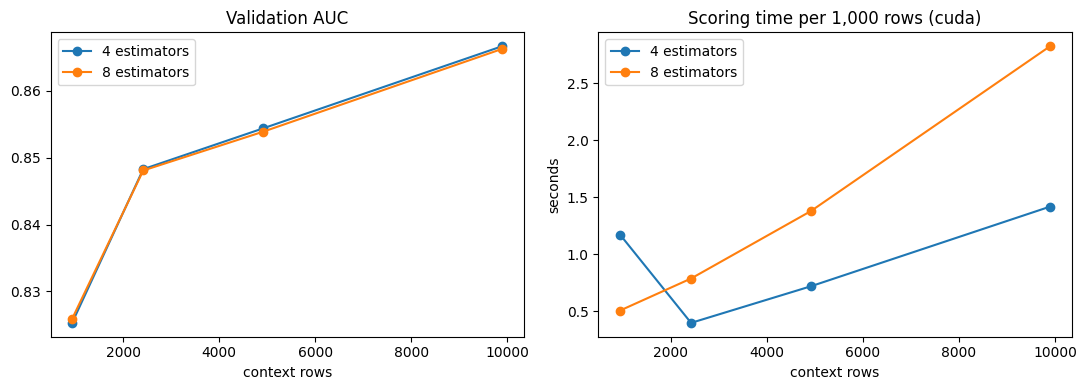

In [5]:
if RUN_SPEED_CHECK:
    speed_idx = tm.stratified_sample(val, val[TARGET], SPEED_ROWS, RANDOM_STATE)
    speed_val = val.loc[speed_idx]
    results = []
    for n_ctx in SPEED_GRID["context_rows"]:
        for n_est in SPEED_GRID["n_estimators"]:
            t0 = time.perf_counter()
            m = tm.fit(train, y_train, context_rows=n_ctx, n_estimators=n_est, model_version=MODEL_VERSION)
            t1 = time.perf_counter()
            p = tm.predict_proba(m, speed_val)[:, 1]
            t2 = time.perf_counter()
            results.append({"context_rows": len(m.y_context), "n_estimators": n_est, "fit_s": t1 - t0,
                            "predict_s_per_1k_rows": (t2 - t1) / len(speed_val) * 1000,
                            "AUC": roc_auc_score(speed_val[TARGET], p)})
            print(results[-1], flush=True)
    speed = pd.DataFrame(results).round(4)
    speed.to_csv(OUT_DIR / "speed_check.csv", index=False)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for n_est, g in speed.groupby("n_estimators"):
        axes[0].plot(g["context_rows"], g["AUC"], marker="o", label=f"{n_est} estimators")
        axes[1].plot(g["context_rows"], g["predict_s_per_1k_rows"], marker="o", label=f"{n_est} estimators")
    axes[0].set(title="Validation AUC", xlabel="context rows")
    axes[1].set(title=f"Scoring time per 1,000 rows ({DEVICE})", xlabel="context rows", ylabel="seconds")
    for a in axes:
        a.legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR / "speed_check.png", dpi=150)
    plt.show()

## 4. Final model

`tm.fit()` — the same function the stability step will call — on the full train split: it draws
the stratified context and fits TabPFN on it. The table compares the context's make-up with the full
training split.

In [6]:
t0 = time.perf_counter()
model = tm.fit(train, y_train, context_rows=CONTEXT_ROWS, n_estimators=N_ESTIMATORS,
               model_version=MODEL_VERSION)
FIT_SECONDS = time.perf_counter() - t0

context_race = train.loc[model.X_context.index, "derived_race"]
composition = pd.DataFrame({"context": context_race.value_counts(normalize=True),
                            "full_train": train["derived_race"].value_counts(normalize=True)}).round(4)
print(f"fitted in {FIT_SECONDS:.1f}s on {DEVICE} | context: {len(model.y_context):,} rows, "
      f"approval rate {model.y_context.mean():.4f} vs full train {y_train.mean():.4f}")
display(composition.sort_values("full_train", ascending=False))

fitted in 3.2s on cuda | context: 9,898 rows, approval rate 0.7786 vs full train 0.7751


,context,full_train
derived_race,,
White,0.6612,0.6557
Race Not Available,0.1695,0.1688
Black or African American,0.0813,0.0820
Asian,0.0588,0.0593
Joint,0.0209,0.0219
American Indian or Alaska Native,0.0059,0.0073
2 or more minority races,0.0013,0.0025
Native Hawaiian or Other Pacific Islander,0.0010,0.0023
Free Form Text Only,NaN,0.0002


## 5. Statistical performance (validation)

- **Ranking:** ROC-AUC (primary), Gini (= 2·AUC − 1), KS.
- **Probability quality:** Brier score, log loss, reliability diagram.
- **Classes:** PR-AUC for approvals and for denials — the denial one is more sensitive to how well
  the ~22% minority class is ranked.
- **At `THRESHOLD`:** accuracy, precision, recall, specificity, F1, as in the log-reg notebook. The
  decision threshold from the team's P&L is applied later, not here.

**Scores depend slightly on the batch.** TabPFN runs the context and the rows being scored through
the transformer together, and some of its internal normalisation uses statistics of that whole
input. The same applicant can get a score that differs by up to about 0.005 depending on which other
rows are in the same call (measured with TabPFN-2.5 on this data; unchanged at float64 and on one
thread, so it comes from the model's design, not rounding). `tm.predict_proba` scores in fixed
batches of `tm.BATCH_ROWS` rows in the order given, so the same rows in the same order give the same
scores.

In [7]:
def evaluate(y, p, threshold: float = THRESHOLD) -> dict:
    y, p = np.asarray(y), np.asarray(p)
    pred = (p >= threshold).astype(int)
    fpr, tpr, _ = roc_curve(y, p)
    auc = roc_auc_score(y, p)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    return {
        "rows": len(y), "ROC-AUC": auc, "Gini": 2 * auc - 1, "KS": float(np.max(tpr - fpr)),
        "Brier": brier_score_loss(y, p), "Log loss": log_loss(y, p),
        "PR-AUC (approval)": average_precision_score(y, p),
        "PR-AUC (denial)": average_precision_score(1 - y, 1 - p),
        "Accuracy": accuracy_score(y, pred), "Precision": precision_score(y, pred, zero_division=0),
        "Recall (TPR)": recall_score(y, pred, zero_division=0),
        "Specificity (TNR)": tn / (tn + fp) if tn + fp else np.nan, "F1": f1_score(y, pred),
        "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
    }


def score(df: pd.DataFrame, n: int | None):
    rows = df.loc[tm.stratified_sample(df, df[TARGET], n, RANDOM_STATE)]
    t0 = time.perf_counter()
    p = tm.predict_proba(model, rows)[:, 1]
    seconds = time.perf_counter() - t0
    print(f"scored {len(rows):,} rows in {seconds / 60:.1f} min")
    return rows, p, seconds


val_rows, p_val, VAL_SECONDS = score(val, VAL_ROWS)
val_metrics = evaluate(val_rows[TARGET], p_val)
pd.Series(val_metrics).round(4).to_frame("validation")

scored 19,904 rows in 0.1 min


,validation
rows,19904.0000
ROC-AUC,0.8731
Gini,0.7461
KS,0.5909
Brier,0.0962
Log loss,0.3250
PR-AUC (approval),0.9477
PR-AUC (denial),0.7684
Accuracy,0.8769
Precision,0.8822


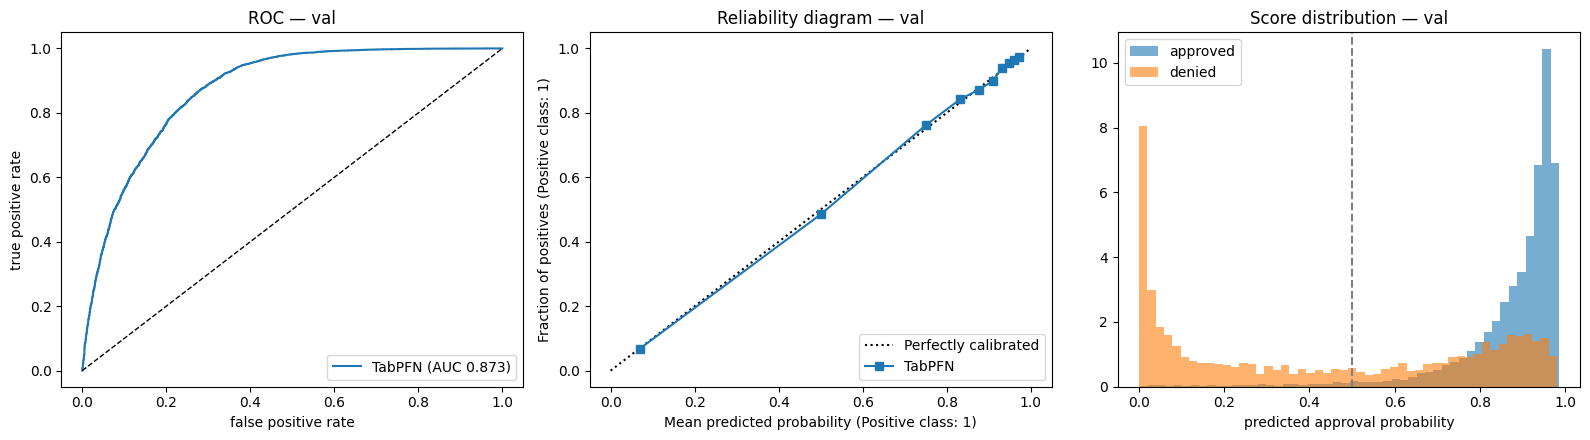

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fpr, tpr, _ = roc_curve(val_rows[TARGET], p_val)
axes[0].plot(fpr, tpr, label=f"TabPFN (AUC {val_metrics['ROC-AUC']:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set(title="ROC — val", xlabel="false positive rate", ylabel="true positive rate")
axes[0].legend()
CalibrationDisplay.from_predictions(val_rows[TARGET], p_val, n_bins=10, strategy="quantile",
                                    name="TabPFN", ax=axes[1])
axes[1].set_title("Reliability diagram — val")
for label, name in [(1, "approved"), (0, "denied")]:
    axes[2].hist(p_val[val_rows[TARGET].to_numpy() == label], bins=50, alpha=0.6, label=name, density=True)
axes[2].axvline(THRESHOLD, color="grey", ls="--")
axes[2].set(title="Score distribution — val", xlabel="predicted approval probability")
axes[2].legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "validation_performance.png", dpi=150)
plt.show()

## 6. Statistical performance (test)

Everything above was decided on validation rows only. The test split is scored here, once, with the
settings already fixed; changing settings after looking at these numbers would make test a second
validation set.

In [9]:
test_rows, p_test, TEST_SECONDS = score(test, TEST_ROWS)
test_metrics = evaluate(test_rows[TARGET], p_test)
pd.DataFrame({"validation": val_metrics, "test": test_metrics}).round(4)

scored 1,368,986 rows in 7.2 min


,validation,test
rows,19904.0000,1.368986e+06
ROC-AUC,0.8731,8.752000e-01
Gini,0.7461,7.505000e-01
KS,0.5909,5.943000e-01
Brier,0.0962,9.530000e-02
Log loss,0.3250,3.217000e-01
PR-AUC (approval),0.9477,9.491000e-01
PR-AUC (denial),0.7684,7.744000e-01
Accuracy,0.8769,8.776000e-01
Precision,0.8822,8.828000e-01


## 7. Save artifacts

To load the model elsewhere (interpretability, stability, fairness notebooks), put `src/` on the path
first, because the pickled object refers to the `tabpfn_model` module. The first prediction rebuilds
the network from the saved context (~1 s on a GPU), on whatever device that machine has:

```python
import sys; sys.path.insert(0, "src")
import joblib, tabpfn_model as tm
model = joblib.load("models/tabpfn_model.joblib")
p = tm.predict_proba(model, df)[:, 1]      # df = cleaned rows, e.g. pd.read_parquet("data/processed/test.parquet")
```

The prediction files follow the log-reg notebook's `test_predictions_with_sensitive.parquet` layout,
plus `row_nr` as the index.

In [10]:
def predictions_table(rows: pd.DataFrame, p: np.ndarray) -> pd.DataFrame:
    out = rows[AUDIT_COLS].copy()
    out["true_target"] = rows[TARGET].to_numpy()
    out["predicted_probability"] = p
    out["predicted_label"] = (p >= THRESHOLD).astype(int)
    return out


predictions_table(val_rows, p_val).to_parquet(OUT_DIR / "val_predictions_with_sensitive.parquet")
predictions_table(test_rows, p_test).to_parquet(OUT_DIR / "test_predictions_with_sensitive.parquet")
joblib.dump(model, MODELS_DIR / "tabpfn_model.joblib")

run_config = {
    "model": f"TabPFN {MODEL_VERSION}", "device": DEVICE, "random_state": RANDOM_STATE,
    "context_rows": len(model.y_context), "n_estimators": N_ESTIMATORS, "val_rows": len(val_rows),
    "test_rows": len(test_rows), "test_is_full_split": TEST_ROWS is None, "threshold": THRESHOLD,
    "batch_rows": tm.BATCH_ROWS, "features": tm.FEATURES, "excluded": tm.EXCLUDED,
    "strata": [TARGET] + tm.STRATA_COLS,
    "timings_s": {"fit": FIT_SECONDS, "val_scoring": VAL_SECONDS, "test_scoring": TEST_SECONDS},
    "versions": VERSIONS,
}
(OUT_DIR / "run_config.json").write_text(json.dumps(run_config, indent=2))

summary = pd.DataFrame({"validation": val_metrics, "test": test_metrics}).round(5)
(OUT_DIR / "metrics_summary.txt").write_text(
    f"TABPFN ({MODEL_VERSION}) — context {len(model.y_context):,} rows, {N_ESTIMATORS} estimators, "
    f"threshold {THRESHOLD}, device {DEVICE}\n"
    f"test rows: {len(test_rows):,} ({'full split' if TEST_ROWS is None else 'stratified subset'})\n\n"
    + summary.to_string() + "\n")

# The saved model must reproduce the saved scores once reloaded (which rebuilds the network from the
# saved context). Checked on the first batch of test rows, scored exactly as above.
reloaded = joblib.load(MODELS_DIR / "tabpfn_model.joblib")
n_check = min(tm.BATCH_ROWS, len(test_rows))
diff = np.abs(tm.predict_proba(reloaded, test_rows.iloc[:n_check])[:, 1] - p_test[:n_check])
print(f"reloaded vs saved scores on {n_check:,} rows: mean |diff| {diff.mean():.1e}, max {diff.max():.1e}")
assert diff.mean() < 1e-4 and diff.max() < 1e-2, "reloaded model does not reproduce the saved scores"

for f in [MODELS_DIR / "tabpfn_model.joblib"] + sorted(OUT_DIR.iterdir()):
    print(f"  {str(f):60s} {f.stat().st_size / 1e6:9.2f} MB")

reloaded vs saved scores on 20,000 rows: mean |diff| 0.0e+00, max 0.0e+00
  ../models/tabpfn_model.joblib                                     2.55 MB
  ../data/tabpfn-results/feature_audit.csv                          0.00 MB
  ../data/tabpfn-results/metrics_summary.txt                        0.00 MB
  ../data/tabpfn-results/run_config.json                            0.00 MB
  ../data/tabpfn-results/speed_check.csv                            0.00 MB
  ../data/tabpfn-results/speed_check.png                            0.08 MB
  ../data/tabpfn-results/tabpfn_context.parquet                     0.32 MB
  ../data/tabpfn-results/tabpfn_model.joblib                      895.52 MB
  ../data/tabpfn-results/test_features.parquet                     29.27 MB
  ../data/tabpfn-results/test_predictions_with_sensitive.parquet     17.58 MB
  ../data/tabpfn-results/val_features.parquet                       0.57 MB
  ../data/tabpfn-results/val_predictions_with_sensitive.parquet      0.32 MB
  ../data/t

## 8. Notes

- **Licence.** TabPFN-3.5's weights (`tabpfn-3-5-license-v1.0`) allow testing, evaluation and
  benchmarking, but not commercial use or internal commercial decision-making without a separate
  commercial licence. A lender could not deploy this model as it is.
- **Cost.** No training or tuning, but every prediction re-reads the context, so scoring — and any
  method that scores many modified copies of the data, like SHAP — is much slower than for the
  other two models, and needs a GPU at this data size. The timings in `run_config.json` document
  this.